In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
#IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Conv2D, MaxPooling2D, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

from sklearn.metrics import classification_report, confusion_matrix

sns.set_style("whitegrid")

In [25]:
#TF version

print('Tensorflow version: ', tf.__version__)

Tensorflow version:  2.19.0


In [26]:
#LOAD DATASET

with h5py.File('/content/SVHN_single_grey1.h5', 'r') as hf:
    X_train = np.array(hf['X_train'])
    y_train = np.array(hf['y_train'])
    X_val = np.array(hf['X_val'])
    y_val = np.array(hf['y_val'])
    X_test = np.array(hf['X_test'])
    y_test = np.array(hf['y_test'])

In [27]:
#CHECK NUMBER OF IMAGES IN TRAINING AND TESTING DATASET

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)
print("Test labels shape:", y_test.shape)

Training set shape: (42000, 32, 32)
Validation set shape: (60000, 32, 32)
Test set shape: (18000, 32, 32)
Training labels shape: (42000,)
Validation labels shape: (60000,)
Test labels shape: (18000,)


In [28]:
#OBSERVATION

## The dataset is already split into training, validation, and test sets. Each image is a grayscale image of size 32 × 32 pixels, and the target variable contains digit labels from 0 to 9.

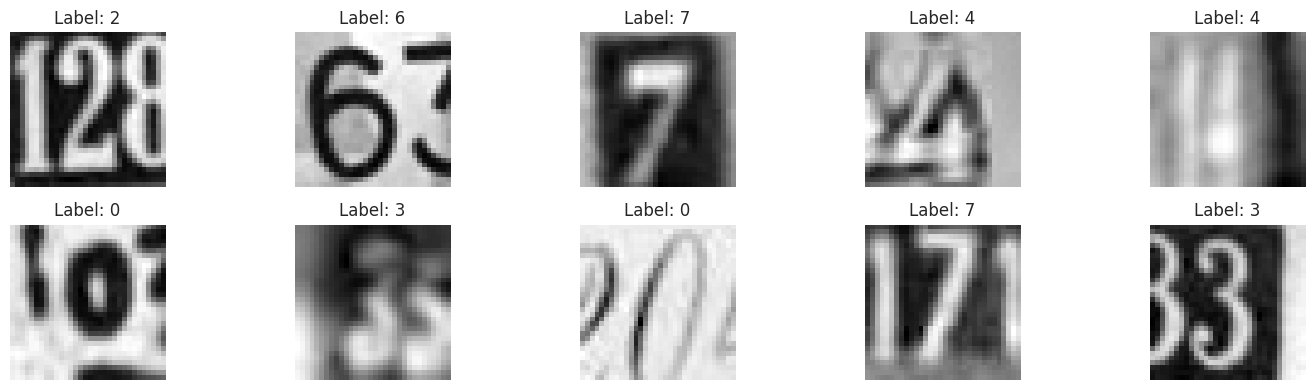

In [29]:
#IMAGE VISUALIZATION

plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
#DATA PREPARATION

print("Shape of first image:", X_train[0].shape)
print("\nPixel values of first image:\n")
print(X_train[0])

Shape of first image: (32, 32)

Pixel values of first image:

[[ 33.0704  30.2601  26.852  ...  71.4471  58.2204  42.9939]
 [ 25.2283  25.5533  29.9765 ... 113.0209 103.3639  84.2949]
 [ 26.2775  22.6137  40.4763 ... 113.3028 121.775  115.4228]
 ...
 [ 28.5502  36.212   45.0801 ...  24.1359  25.0927  26.0603]
 [ 38.4352  26.4733  23.2717 ...  28.1094  29.4683  30.0661]
 [ 50.2984  26.0773  24.0389 ...  49.6682  50.853   53.0377]]


In [31]:
# NORMALIZE TRAIN AND TEST DATA


## FLATTEN
X_train_ann = X_train.reshape(X_train.shape[0], 32 * 32)
X_val_ann = X_val.reshape(X_val.shape[0], 32 * 32)
X_test_ann = X_test.reshape(X_test.shape[0], 32 * 32)

print("Reshaped training data shape:", X_train_ann.shape)
print("Reshaped validation data shape:", X_val_ann.shape)
print("Reshaped test data shape:", X_test_ann.shape)


## NORMALIZATION
X_train_ann = X_train_ann / 255.0
X_val_ann = X_val_ann / 255.0
X_test_ann = X_test_ann / 255.0

## SHAPE CHECK
print("Training data shape after normalization:", X_train_ann.shape)
print("Validation data shape after normalization:", X_val_ann.shape)
print("Test data shape after normalization:", X_test_ann.shape)

## ONE-HOT ENCODING
y_train_ann = to_categorical(y_train, 10)
y_val_ann = to_categorical(y_val, 10)
y_test_ann = to_categorical(y_test, 10)

print("Shape of y_train after one-hot encoding:", y_train_ann.shape)
print("Shape of y_val after one-hot encoding:", y_val_ann.shape)
print("Shape of y_test after one-hot encoding:", y_test_ann.shape)

Reshaped training data shape: (42000, 1024)
Reshaped validation data shape: (60000, 1024)
Reshaped test data shape: (18000, 1024)
Training data shape after normalization: (42000, 1024)
Validation data shape after normalization: (60000, 1024)
Test data shape after normalization: (18000, 1024)
Shape of y_train after one-hot encoding: (42000, 10)
Shape of y_val after one-hot encoding: (60000, 10)
Shape of y_test after one-hot encoding: (18000, 10)


In [32]:
#OBSERVATION

## For the ANN models, each 32 × 32 image was flattened into a 1,024-dimensional vector. Pixel values were normalized to the [0, 1] range to improve training stability and convergence. The target labels were one-hot encoded to make them compatible with the multiclass softmax output layer.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,010 (265.66 KB)

 Trainable params: 68,010 (265.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1148 - loss: 2.2983 - val_accuracy: 0.1635 - val_loss: 2.2602
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2788 - loss: 2.0657 - val_accuracy: 0.3845 - val_loss: 1.8280
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4470 - loss: 1.6704 - val_accuracy: 0.4987 - val_loss: 1.5452
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5191 - loss: 1.4720 - val_accuracy: 0.5445 - val_loss: 1.4111
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5597 - loss: 1.3627 - val_accuracy: 0.5643 - val_loss: 1.3395
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5810 - loss: 1.2993 - val_accuracy: 0.5838 - val_loss: 1.2820
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5975 - loss: 1.2567 - val_accuracy: 0.5986 - val_loss: 1.2384
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6082 - loss: 1.2264 - val_accuracy: 0.

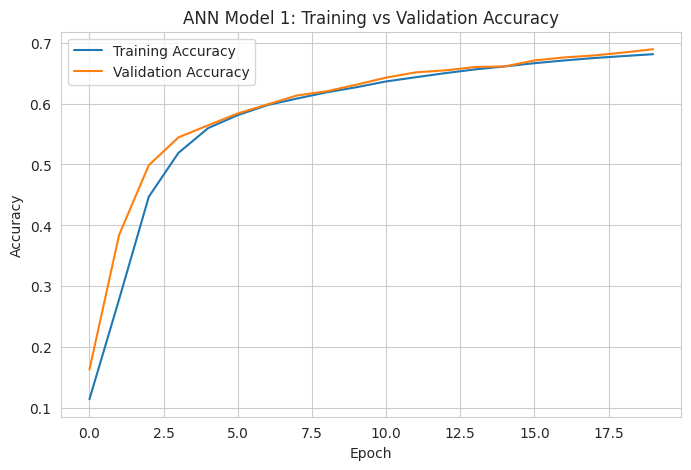

In [33]:
#MODEL BUILDING

## Fix the seed for random number generators
np.random.seed(42)
tf.random.set_seed(42)

## Build and train an ANN model as per the above mentioned architecture.
def nn_model_1():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1024,)),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

model_1 = nn_model_1()
model_1.summary()

history_model_1 = model_1.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    batch_size=128,
    verbose=1,
    epochs=20
)

#Plot the Training and Validation Accuracies
plt.figure(figsize=(8, 5))
plt.plot(history_model_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model 1: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



In [34]:
#OBSERVATIONS

#The ANN model shows a steady and consistent improvement in both training and validation accuracy across epochs, indicating that the model is effectively learning patterns from the data. Additionally, the smooth convergence of both curves suggests that the learning rate is appropriate and that the model capacity is neither too low nor excessively high for this baseline architecture. However, the overall performance remains moderate (~69% accuracy).

In [35]:
#Clear previous model
K.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,250 (1.18 MB)

 Trainable params: 310,186 (1.18 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1026 - loss: 2.3455 - val_accuracy: 0.1037 - val_loss: 2.3043
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1463 - loss: 2.2313 - val_accuracy: 0.2704 - val_loss: 2.0994
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3589 - loss: 1.7720 - val_accuracy: 0.4539 - val_loss: 1.5511
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5132 - loss: 1.4398 - val_accuracy: 0.5325 - val_loss: 1.3800
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5769 - loss: 1.2854 - val_accuracy: 0.6195 - val_loss: 1.1760
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6062 - loss: 1.2063 - val_accuracy: 0.6594 - val_loss: 1.0688
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6385 - loss: 1.1264 - val_accuracy: 0.6589 - val_loss: 1.0613
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6527 - loss: 1.0809 - val_accu

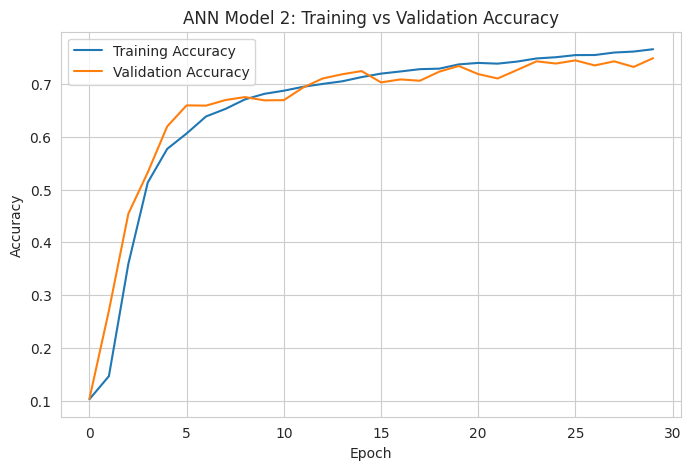

In [36]:
#Second model architecture

#Build and train the new ANN model as per the above mentioned architecture
def nn_model_2():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(1024,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(10, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )
    return model

model_2 = nn_model_2()
model_2.summary()

history_model_2 = model_2.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    batch_size=128,
    verbose=1,
    epochs=30
)

#Plot the Training and Validation Accuracies and write down your Observations
plt.figure(figsize=(8, 5))
plt.plot(history_model_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model 2: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [37]:
#OBSERVATIONS

#The second ANN model demonstrates a clear improvement over the first architecture, achieving higher training and validation accuracy. This improvement can be attributed to the increased depth and number of neurons, which allow the model to capture more complex patterns in the data. The model reaches approximately 75% validation accuracy, indicating that the additional layers and regularization techniques (such as dropout and batch normalization) enhance generalization performance. The diminishing performance gains despite increased model complexity suggest that further improvements using ANN architectures alone may be limited. This indicates that a different modeling approach, specifically one that preserves spatial information, is required.


563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report for ANN Model 2:

              precision    recall  f1-score   support

           0       0.80      0.77      0.78      1814
           1       0.65      0.84      0.73      1828
           2       0.79      0.77      0.78      1803
           3       0.65      0.76      0.70      1719
           4       0.78      0.81      0.79      1812
           5       0.78      0.67      0.72      1768
           6       0.86      0.69      0.77      1832
           7       0.73      0.83      0.77      1808
           8       0.73      0.72      0.72      1812
           9       0.85      0.65      0.74      1804

    accuracy                           0.75     18000
   macro avg       0.76      0.75      0.75     18000
weighted avg       0.76      0.75      0.75     18000



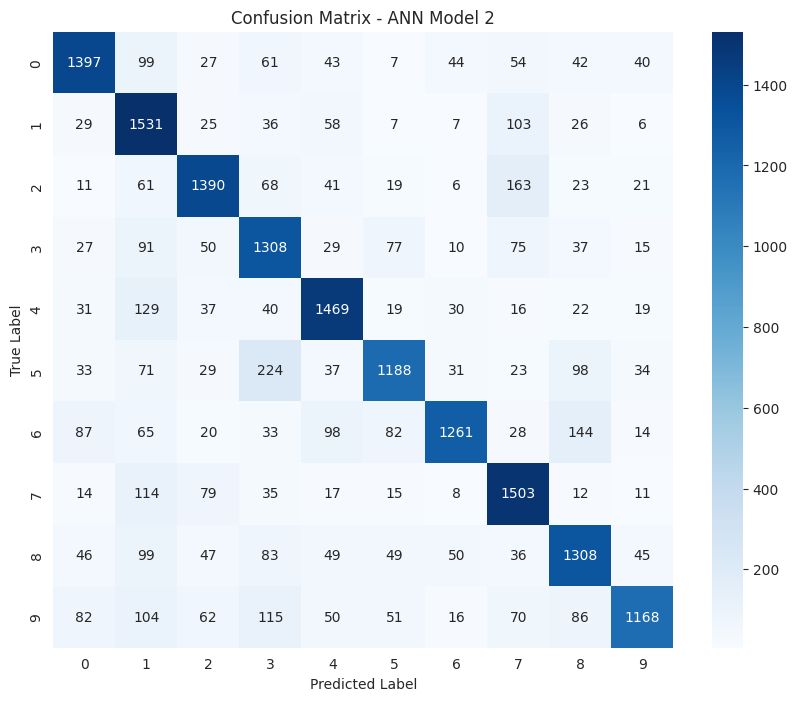

Test Loss (ANN Model 2): 0.7982
Test Accuracy (ANN Model 2): 0.7513


In [38]:
#Predictions on test data

y_pred_prob_ann = model_2.predict(X_test_ann)
y_pred_ann = np.argmax(y_pred_prob_ann, axis=1)
y_true_ann = np.argmax(y_test_ann, axis=1)

print('Classification Report for ANN Model 2:\n')
print(classification_report(y_true_ann, y_pred_ann))

cm_ann = confusion_matrix(y_true_ann, y_pred_ann)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Print the classification report and the confusion matrix for the test predictions.
test_loss_ann, test_acc_ann = model_2.evaluate(X_test_ann, y_test_ann, verbose=0)
print(f'Test Loss (ANN Model 2): {test_loss_ann:.4f}')
print(f'Test Accuracy (ANN Model 2): {test_acc_ann:.4f}')

In [39]:
#OBSERVATIONS

#The ANN Model 2 achieves a test accuracy of approximately 75%, indicating a significant improvement over the baseline ANN model. The consistency between validation and test performance suggests that the model generalizes well to unseen data. The classification report shows relatively balanced precision and recall across most classes, indicating that the model does not heavily favor any particular digit. However, certain digits exhibit lower performance due to visual similarity. For example, digits such as 3 and 5, as well as 4 and 9, are occasionally confused. This behavior is also reflected in the confusion matrix, where misclassifications tend to occur between digits with similar shapes or overlapping visual patterns.  These errors are expected because the ANN processes images as flattened vectors, which removes spatial relationships between pixels. As a result, the model struggles to distinguish subtle structural differences between visually similar digits. The confusion patterns indicate that the model relies primarily on global intensity patterns rather than localized structural features, which limits its ability to differentiate between digits with similar shapes. This limitation reinforces the need for convolutional architectures that can capture spatial hierarchies in the data.

In [40]:
#USING CNNs

In [41]:
#LOAD DATA AND SPLIT INTO TRAINING AND TESTING DATASETS
with h5py.File('SVHN_single_grey1.h5', 'r') as hf:
    X_train = np.array(hf['X_train'])
    y_train = np.array(hf['y_train'])
    X_test = np.array(hf['X_test'])
    y_test = np.array(hf['y_test'])

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('Training labels shape:', y_train.shape)
print('Test labels shape:', y_test.shape)

Training set shape: (42000, 32, 32)
Test set shape: (18000, 32, 32)
Training labels shape: (42000,)
Test labels shape: (18000,)


In [42]:
#DATA PREPARATION

print('Original training data shape:', X_train.shape)
print('Original test data shape:', X_test.shape)
print('Example label:', y_train[0])

X_train_cnn = X_train.reshape(X_train.shape[0], 32, 32, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], 32, 32, 1)

X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print('New training data shape:', X_train_cnn.shape)
print('New test data shape:', X_test_cnn.shape)

Original training data shape: (42000, 32, 32)
Original test data shape: (18000, 32, 32)
Example label: 2
New training data shape: (42000, 32, 32, 1)
New test data shape: (18000, 32, 32, 1)


In [43]:
#One-hot encode the labels in the target variable y_train and y_test
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)

print('Shape of y_train after one-hot encoding:', y_train_cnn.shape)
print('Shape of y_test after one-hot encoding:', y_test_cnn.shape)

Shape of y_train after one-hot encoding: (42000, 10)
Shape of y_test after one-hot encoding: (18000, 10)


In [44]:
#OBSERVATIONS
#The original dataset consists of grayscale images of size 32 × 32, which are initially stored as 2D arrays. For compatibility with convolutional neural networks, the data was reshaped to include a channel dimension, resulting in an input shape of (32, 32, 1). This transformation is important because CNNs expect image data with explicit spatial structure and channel information. By preserving the 2D structure of the images, the model can learn local patterns such as edges, textures, and shapes through convolutional filters. The target labels were one-hot encoded to match the softmax output layer used in multiclass classification tasks. This ensures that the model can output probability distributions across the 10 digit classes. Unlike ANN models, which require flattening the input and consequently lose spatial relationships, CNNs retain the spatial arrangement of pixels. This allows the model to capture hierarchical features, making it significantly more effective for image recognition tasks.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,306 (1.02 MB)

 Trainable params: 267,306 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - accuracy: 0.5395 - loss: 1.3528 - val_accuracy: 0.7969 - val_loss: 0.6963
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 78s 75ms/step - accuracy: 0.8387 - loss: 0.5540 - val_accuracy: 0.8381 - val_loss: 0.5579
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.8703 - loss: 0.4477 - val_accuracy: 0.8561 - val_loss: 0.5064
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.8889 - loss: 0.3838 - val_accuracy: 0.8663 - val_loss: 0.4893
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.9026 - loss: 0.3367 - val_accuracy: 0.8711 - val_loss: 0.4872
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.9145 - loss: 0.2968 - val_accuracy: 0.8707 - val_loss: 0.5036
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.9226 - loss: 0.2647 - val_accuracy: 0.8694 - val_loss: 0.5239
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 80s 76ms/step - accuracy: 0.9296 -

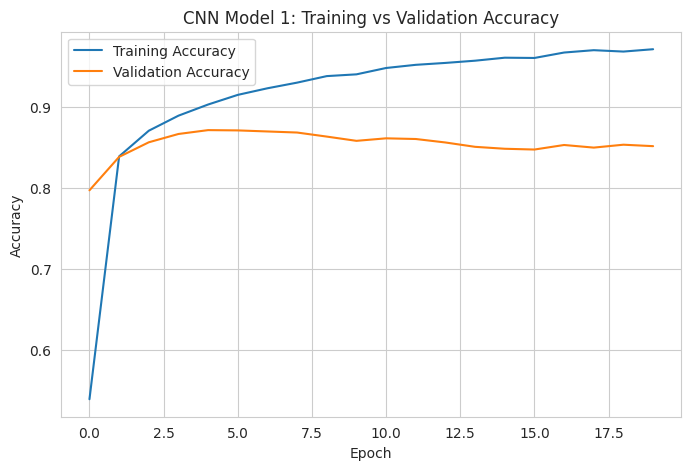

In [45]:
#MODEL BUILDING

#Build and train a CNN model as per the above mentioned architecture
def cnn_model_1():
    model = Sequential([
        Conv2D(16, (3, 3), padding='same', input_shape=(32, 32, 1)),
        LeakyReLU(negative_slope=0.1),
        Conv2D(32, (3, 3), padding='same'),
        LeakyReLU(negative_slope=0.1),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(10, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

cnn_1 = cnn_model_1()
cnn_1.summary()

history_cnn_1 = cnn_1.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    batch_size=32,
    verbose=1,
    epochs=20
)

#Plot the Training and Validation Accuracies
plt.figure(figsize=(8, 5))
plt.plot(history_cnn_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model 1: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [46]:
#OBSERVATIONS
#The first CNN model shows a substantial improvement over both ANN architectures. Training accuracy increases rapidly and reaches approximately 97%, while validation accuracy stabilizes around 85%, confirming that the convolutional architecture is much more effective for image classification than fully connected networks. The first CNN model shows a substantial improvement over both ANN architectures. Training accuracy increases rapidly and reaches approximately 97%, while validation accuracy stabilizes around 85%, confirming that the convolutional architecture is much more effective for image classification than fully connected networks. This performance gain is expected because CNNs preserve the spatial structure of the images and are able to learn local features such as edges, curves, and digit shapes through convolutional filters. These features are especially important in the SVHN dataset, where digits may vary in thickness, alignment, and visual appearance. Therefore, although CNN Model 1 clearly outperforms the ANN models, its generalization ability could still be improved through stronger regularization, better architectural design, or training control strategies such as dropout, batch normalization, or early stopping. The learning curves suggest that the model captures relevant image features very effectively, but its capacity may be too high relative to the regularization applied. As a result, the network starts memorizing training-specific patterns rather than continuing to improve its performance on unseen validation samples.

In [47]:
#Clear previous model
K.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,362 (642.04 KB)

 Trainable params: 164,170 (641.29 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 128s 469ms/step - accuracy: 0.5593 - loss: 1.2935 - val_accuracy: 0.1360 - val_loss: 2.4706
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 141s 464ms/step - accuracy: 0.8023 - loss: 0.6424 - val_accuracy: 0.8031 - val_loss: 0.6758
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 125s 474ms/step - accuracy: 0.8395 - loss: 0.5239 - val_accuracy: 0.8857 - val_loss: 0.3921
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 126s 478ms/step - accuracy: 0.8579 - loss: 0.4571 - val_accuracy: 0.8881 - val_loss: 0.3774
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 134s 511ms/step - accuracy: 0.8733 - loss: 0.4168 - val_accuracy: 0.8820 - val_loss: 0.4072
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 141s 509ms/step - accuracy: 0.8793 - loss: 0.3872 - val_accuracy: 0.9018 - val_loss: 0.3625
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 131s 497ms/step - accuracy: 0.8892 - loss: 0.3589 - val_accuracy: 0.8688 - val_loss: 0.4487
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 133s 508ms/step - accuracy: 0.8971 -

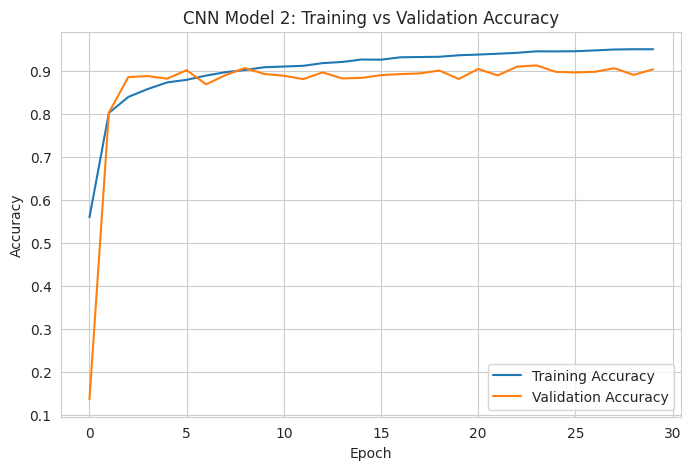

In [48]:
#Build and train the second CNN model as per the above mentioned architecture.

def cnn_model_2():
    model = Sequential([
        Conv2D(16, (3, 3), padding='same', input_shape=(32, 32, 1)),
        LeakyReLU(negative_slope=0.1),
        Conv2D(32, (3, 3), padding='same'),
        LeakyReLU(negative_slope=0.1),
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same'),
        LeakyReLU(negative_slope=0.1),
        Conv2D(64, (3, 3), padding='same'),
        LeakyReLU(negative_slope=0.1),
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),
        Flatten(),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

cnn_2 = cnn_model_2()
cnn_2.summary()

history_cnn_2 = cnn_2.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    batch_size=128,
    verbose=1,
    epochs=30
)

#Plot the Training and Validation accuracies
plt.figure(figsize=(8, 5))
plt.plot(history_cnn_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model 2: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [49]:
#OBSERVATIONS

#The second CNN model shows a clear improvement in generalization compared to CNN Model 1. While the training accuracy reaches approximately 95%, the validation accuracy stabilizes around 90–91%, significantly reducing the gap between training and validation performance. This improvement can be attributed to the use of regularization techniques such as dropout and batch normalization, which help prevent overfitting and improve the model's ability to generalize to unseen data. This improvement can be attributed to the use of regularization techniques such as dropout and batch normalization, which help prevent overfitting and improve the model's ability to generalize to unseen data. Overall, CNN Model 2 achieves the best performance among all models tested, demonstrating that combining convolutional layers with proper regularization leads to superior results in image classification tasks. CNN Model 2 achieves the best balance between performance and generalization, significantly reducing overfitting while improving validation accuracy compared to previous models.

563/563 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step
Classification Report for CNN Model 2:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1814
           1       0.89      0.91      0.90      1828
           2       0.94      0.92      0.93      1803
           3       0.92      0.84      0.88      1719
           4       0.93      0.91      0.92      1812
           5       0.86      0.93      0.89      1768
           6       0.89      0.89      0.89      1832
           7       0.94      0.92      0.93      1808
           8       0.91      0.88      0.90      1812
           9       0.92      0.88      0.90      1804

    accuracy                           0.90     18000
   macro avg       0.91      0.90      0.90     18000
weighted avg       0.91      0.90      0.90     18000



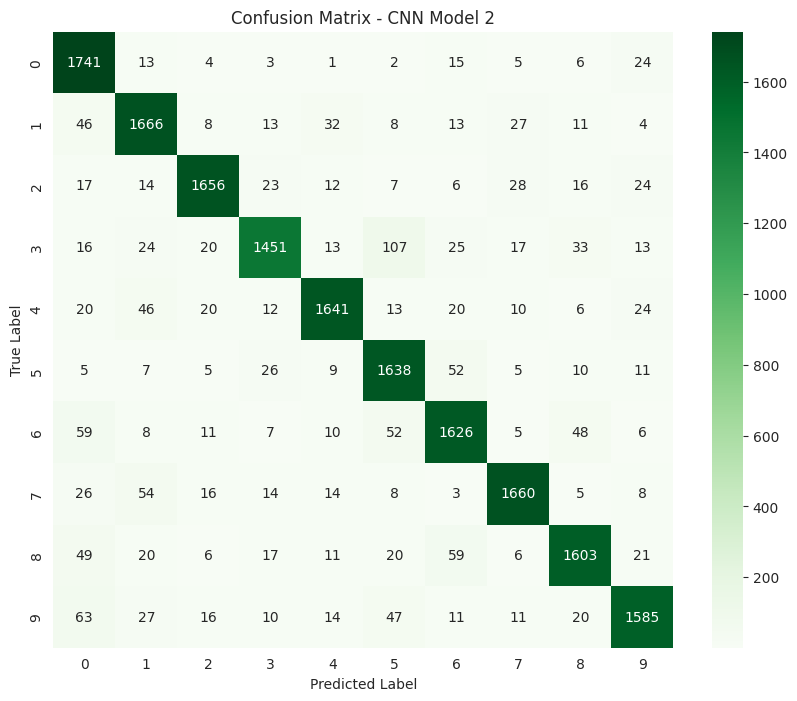

In [50]:
#Make predictions on the test data using the second model

y_pred_prob_cnn = cnn_2.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)
y_true_cnn = np.argmax(y_test_cnn, axis=1)

print('Classification Report for CNN Model 2:\n')
print(classification_report(y_true_cnn, y_pred_cnn))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - CNN Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [51]:
#Write your final observations on the performance of the model on the test data.

test_loss_cnn, test_acc_cnn = cnn_2.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f'Test Loss (CNN Model 2): {test_loss_cnn:.4f}')
print(f'Test Accuracy (CNN Model 2): {test_acc_cnn:.4f}')

Test Loss (CNN Model 2): 0.5207
Test Accuracy (CNN Model 2): 0.9037


In [ ]:
#FINAL OBSERVATIONS
#The model achieved a test accuracy of ~90.37%, indicating strong generalization performance.
#Precision, recall, and F1-scores are consistently high (~0.88–0.94) across most classes.
#The confusion matrix shows a strong diagonal pattern, meaning most predictions are correct.
#Compared to Model 1, performance improved due to Batch Normalization and Dropout, reducing overfitting.
#The gap between training and validation accuracy is relatively small, indicating good model stability.
#Overall, the model provides a good balance between accuracy and generalization.